In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

In [18]:
import warnings
warnings.filterwarnings("ignore")

In [2]:
df  = pd.DataFrame({'area' :[2600,3000,3200,3600,4000],'price':[550000,565000,610000,680000,725000]})

In [3]:
df

,area,price
0,2600,550000
1,3000,565000
2,3200,610000
3,3600,680000
4,4000,725000


<Axes: xlabel='area', ylabel='price'>

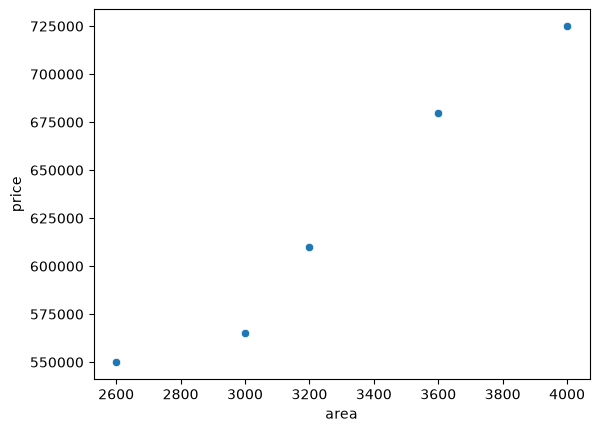

In [ ]:
sns.scatterplot(x='area',y='price',data=df)

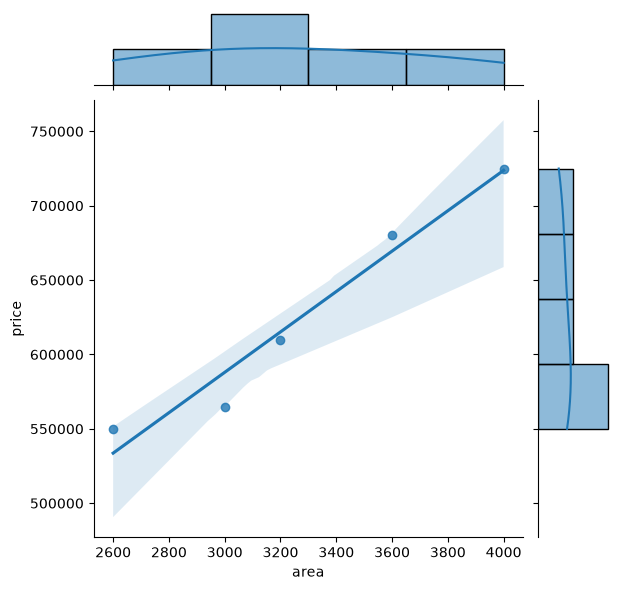

In [ ]:
sns.jointplot(x=df['area'],y=df['price'],kind='reg')    #regression plot

In [11]:
from sklearn.linear_model import LinearRegression

In [12]:
reg = LinearRegression()

In [ ]:
reg.fit(df[['area']],df['price'])    #x_feature is usually 2d

,"fit_intercept fit_intercept: bool, default=TrueWhether to calculate the intercept for this model. If setto False, no intercept will be used in calculations(i.e. data is expected to be centered).",True
,"copy_X copy_X: bool, default=TrueIf True, X will be copied; else, it may be overwritten.",True
,"tol tol: float, default=1e-6The precision of the solution (`coef_`) is determined by `tol` whichspecifies the convergence criterion of the underlying solver. `tol` isset as `atol` and `btol` of :func:`scipy.sparse.linalg.lsqr` whenfitting on sparse training data. `tol` is set as `cond` of:func:`scipy.linalg.lstsq` when fitting on dense training data... versionadded:: 1.7.. versionchanged:: 1.9 Now supported on dense data, interpreted as the `cond` parameter.",1e-06
,"n_jobs n_jobs: int, default=NoneThe number of jobs to use for the computation. This will only providespeedup in case of sufficiently large problems, that is if firstly`n_targets > 1` and secondly `X` is sparse or if `positive` is setto `True`. ``None`` means 1 unless in a:obj:`joblib.parallel_backend` context. ``-1`` means using allprocessors. See :term:`Glossary <n_jobs>` for more details.",None
,"positive positive: bool, default=FalseWhen set to ``True``, forces the coefficients to be positive. Thisoption is only supported for dense arrays.For a comparison between a linear regression model with positive constraintson the regression coefficients and a linear regression without such constraints,see :ref:`sphx_glr_auto_examples_linear_model_plot_nnls.py`... versionadded:: 0.24",False
Name,Type,Value
"coef_ coef_: array of shape (n_features, ) or (n_targets, n_features)Estimated coefficients for the linear regression problem.If multiple targets are passed during the fit (y 2D), thisis a 2D array of shape (n_targets, n_features), while if onlyone target is passed, this is a 1D array of length n_features.","ndarray[float64](1,)",[135.79]
"feature_names_in_ feature_names_in_: ndarray of shape (`n_features_in_`,)Names of features seen during :term:`fit`. Defined only when `X`has feature names that are all strings... versionadded:: 1.0","ndarray[object](1,)",['area']
"intercept_ intercept_: float or array of shape (n_targets,)Independent term in the linear model. Set to 0.0 if`fit_intercept = False`.",float64,1.806e+05
n_features_in_ n_features_in_: intNumber of features seen during :term:`fit`... versionadded:: 0.24,int,1
rank_ rank_: intRank of matrix `X`. Only available when `X` is dense.,int64,np.int64(1)


In [24]:
reg.predict([[3300]])

array([628715.75342466])

In [ ]:
reg.coef_    #this coef_ is coefficient(m) of the  best fit line y = mx+c

array([135.78767123])

In [ ]:
reg.intercept_   #the intercept of the best fit line

np.float64(180616.43835616432)

In [ ]:
#what reg.predict([[3300]]) did was
135.78767123 * 3300 + 180616.43835616432    # y = mx+c

628715.7534151643

LINEAR REGRESSION WITH MULTIPLE VARIABLES

In [28]:
d = pd.DataFrame({'bedrooms' :[3,4,np.nan,3,5],'age':[20,15,18,30,8]})

In [47]:
data = pd.concat([df,d],axis=1)

In [48]:
data    #data is ready with multi variables

,area,price,bedrooms,age
0,2600,550000,3.0,20
1,3000,565000,4.0,15
2,3200,610000,NaN,18
3,3600,680000,3.0,30
4,4000,725000,5.0,8


In [51]:
data.fillna(3,inplace=True)

,area,price,bedrooms,age
0,2600,550000,3.0,20
1,3000,565000,4.0,15
2,3200,610000,3.0,18
3,3600,680000,3.0,30
4,4000,725000,5.0,8


In [52]:
data

,area,price,bedrooms,age
0,2600,550000,3.0,20
1,3000,565000,4.0,15
2,3200,610000,3.0,18
3,3600,680000,3.0,30
4,4000,725000,5.0,8


THE EQUATION HERE IS : y = m1x1 + m2x2 + ... + mnxn +c

In [42]:
from sklearn.linear_model import LinearRegression

In [43]:
reg = LinearRegression()

In [53]:
reg.fit(data[['area','bedrooms','age']],data['price'])

,"fit_intercept fit_intercept: bool, default=TrueWhether to calculate the intercept for this model. If setto False, no intercept will be used in calculations(i.e. data is expected to be centered).",True
,"copy_X copy_X: bool, default=TrueIf True, X will be copied; else, it may be overwritten.",True
,"tol tol: float, default=1e-6The precision of the solution (`coef_`) is determined by `tol` whichspecifies the convergence criterion of the underlying solver. `tol` isset as `atol` and `btol` of :func:`scipy.sparse.linalg.lsqr` whenfitting on sparse training data. `tol` is set as `cond` of:func:`scipy.linalg.lstsq` when fitting on dense training data... versionadded:: 1.7.. versionchanged:: 1.9 Now supported on dense data, interpreted as the `cond` parameter.",1e-06
,"n_jobs n_jobs: int, default=NoneThe number of jobs to use for the computation. This will only providespeedup in case of sufficiently large problems, that is if firstly`n_targets > 1` and secondly `X` is sparse or if `positive` is setto `True`. ``None`` means 1 unless in a:obj:`joblib.parallel_backend` context. ``-1`` means using allprocessors. See :term:`Glossary <n_jobs>` for more details.",None
,"positive positive: bool, default=FalseWhen set to ``True``, forces the coefficients to be positive. Thisoption is only supported for dense arrays.For a comparison between a linear regression model with positive constraintson the regression coefficients and a linear regression without such constraints,see :ref:`sphx_glr_auto_examples_linear_model_plot_nnls.py`... versionadded:: 0.24",False
Name,Type,Value
"coef_ coef_: array of shape (n_features, ) or (n_targets, n_features)Estimated coefficients for the linear regression problem.If multiple targets are passed during the fit (y 2D), thisis a 2D array of shape (n_targets, n_features), while if onlyone target is passed, this is a 1D array of length n_features.","ndarray[float64](3,)","[ 143.62,-6762.5 , 337.5 ]"
"feature_names_in_ feature_names_in_: ndarray of shape (`n_features_in_`,)Names of features seen during :term:`fit`. Defined only when `X`has feature names that are all strings... versionadded:: 1.0","ndarray[object](3,)","['area','bedrooms','age']"
"intercept_ intercept_: float or array of shape (n_targets,)Independent term in the linear model. Set to 0.0 if`fit_intercept = False`.",float64,1.731e+05
n_features_in_ n_features_in_: intNumber of features seen during :term:`fit`... versionadded:: 0.24,int,3
rank_ rank_: intRank of matrix `X`. Only available when `X` is dense.,int64,np.int64(3)


In [54]:
reg.predict([[3300,6,20]])

array([613250.])

In [55]:
reg.coef_

array([  143.625, -6762.5  ,   337.5  ])

In [56]:
reg.intercept_

np.float64(173112.5)